# Phase 1.5 v4 — VIX 외생변수 + IS 확장 Optuna GridSearch (`02_v4_lstm_optuna.ipynb`)

> **목적**: v3 의 best (3ch / IS=750 / emb=63 / RMSE 0.4001) 한계 검증
> **2가지 동시 차원 변경**: VIX 외생변수 추가 + IS 1000/1250 확장

## v3 → v4 차이

| 차원 | v3 | **v4** |
|---|---|---|
| input_channels | `['1ch', '3ch']` | **`['1ch', '3ch', '1ch_vix', '3ch_vix']`** |
| is_len | `[252, 504, 750]` | **`[750, 1000, 1250]`** |
| embargo | `[63, 126]` | **`[63]`** (v3 결과로 126 효과 없음 확인) |
| 외생 데이터 | X | **VIX (CBOE Volatility Index)** |
| 고정 hyperparameter | hidden=32, dropout=0.3, lr=1e-3 | 동일 |

## 검증 가설

| 가설 | 후보 | 기대 효과 |
|---|---|---|
| (a) 변수 + 샘플 부족 | IS 1000, 1250 / VIX 추가 | RMSE 추가 개선 |
| (d) LSTM 자체 한계 | VIX 비선형 신호 | 비선형 capacity 발현 |

## VIX 데이터 — 자동 처리

- **1차 시도**: `raw_data/VIX.csv` 캐시 로드
- **2차 시도**: `yfinance` 로 자동 다운로드 + 캐시 저장
- **분석 기간 절단**: 2016-01-01 ~ 2025-12-31 (SPY/QQQ 와 동일 거래일)

## 사용자 GPU 환경 가이드

### Step 1. 라이브러리 설치 (1회)
```bash
pip install optuna yfinance
```

### Step 2. Run All
- 12 trials × ~80~100초 = **약 15~20분**

### Step 3. 산출 확인
```
results/lstm_optuna_v4/
├── all_trials.csv                (12 trials)
├── best_metrics.json              (최적 조합)
└── lstm_optuna_v4_summary.md      (자동 보고서)
```

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + GPU 감지 + Optuna/yfinance import |
| §2 | 데이터 로드 (SPY/QQQ + **VIX 자동 다운로드**) |
| §3 | 입력 채널 사전 준비 (4 종) |
| §4 | LSTM 학습 함수 — `run_lstm_for_config` |
| §5 | Optuna GridSampler study (12 trials) |
| §6 | 12 trials 비교 표 + 최적 조합 |
| §7 | HAR / EWMA / Naive 와 비교 — 관문 1 재판정 |
| §8 | 시각화 (RMSE bar + interaction effect) |
| §9 | 결론 + summary.md 자동 생성 |


## §1. 환경 부트스트랩 + GPU 감지 + 라이브러리 import

### 라이브러리 설치 안내 (1회)
```bash
pip install optuna yfinance
```


In [1]:
# 환경 부트스트랩
import sys
import json
import time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

# Optuna
try:
    import optuna
    print(f'optuna {optuna.__version__} 로드 완료')
except ImportError:
    print('[ERROR] optuna 미설치 — 터미널에서: pip install optuna')
    raise

# yfinance (VIX 다운로드용)
try:
    import yfinance as yf
    print(f'yfinance {yf.__version__} 로드 완료')
except ImportError:
    print('[ERROR] yfinance 미설치 — 터미널에서: pip install yfinance')
    raise

# GPU 자동 감지
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
optuna 4.8.0 로드 완료
yfinance 1.2.1 로드 완료
사용 device: cuda
  GPU: NVIDIA GeForce RTX 4090


## §2. 데이터 로드 — SPY/QQQ + **VIX 자동 다운로드**

### VIX 처리 흐름
1. `raw_data/VIX.csv` 캐시 존재? → 그대로 사용
2. 미존재 → `yf.download('^VIX', ...)` 자동 다운로드 + 캐시 저장
3. SPY/QQQ 거래일 인덱스에 정렬 (left join)
4. NaN 처리 (전일 forward fill — VIX 휴장 시)


In [2]:
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21
SEQ_LEN = 63
HAR_W_WINDOW = 5
HAR_M_WINDOW = 22


# VIX 로드 함수 (캐시 우선, 미존재 시 다운로드)
def load_vix(start='2009-01-01', end='2026-04-30') -> pd.DataFrame:
    vix_path = RAW_DATA_DIR / 'VIX.csv'
    if vix_path.exists():
        print(f'  [캐시] VIX.csv 로드: {vix_path}')
        df_vix = pd.read_csv(vix_path, index_col=0, parse_dates=True).sort_index()
    else:
        print(f'  [다운로드] yfinance 로 ^VIX 다운로드 중...')
        df_vix = yf.download('^VIX', start=start, end=end, progress=False, auto_adjust=False)
        if df_vix.empty:
            raise RuntimeError('VIX 다운로드 실패. 인터넷 연결 확인.')
        # 멀티인덱스 컬럼이면 단일화 (yfinance 신버전 대응)
        if isinstance(df_vix.columns, pd.MultiIndex):
            df_vix.columns = [c[0] for c in df_vix.columns]
        df_vix.index.name = 'Date'
        df_vix.to_csv(vix_path)
        print(f'  [저장] VIX 캐시: {vix_path}')
    return df_vix


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


# SPY, QQQ 로드 + 분석 기간 절단
print('=' * 70)
print('데이터 로드')
print('=' * 70)

# VIX 먼저 로드 (전체 기간)
print('\n[1] VIX 로드')
df_vix_full = load_vix(start='2009-01-01', end='2026-04-30')
# Close 가 VIX 의 종가 (변동성 지수)
vix_col = 'Close' if 'Close' in df_vix_full.columns else df_vix_full.columns[0]
df_vix_full = df_vix_full[[vix_col]].rename(columns={vix_col: 'VIX'})
print(f'  VIX 데이터 기간: {df_vix_full.index[0].date()} ~ {df_vix_full.index[-1].date()}')
print(f'  n={len(df_vix_full)}, mean={df_vix_full["VIX"].mean():.2f}, std={df_vix_full["VIX"].std():.2f}')


# SPY, QQQ 로드 + VIX 정렬
print('\n[2] SPY, QQQ 로드 + VIX 정렬')
analysis_dict = {}
for tk in ('SPY', 'QQQ'):
    raw = load_ticker_full(tk)
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    # VIX left join (SPY/QQQ 거래일 기준)
    df = df.join(df_vix_full, how='left')
    df['VIX'] = df['VIX'].ffill()  # NaN 시 전일값
    # 1ch / 3ch 입력 사전 준비
    df['log_ret_sq'] = df['log_ret'] ** 2
    df['rv_d'] = df['log_ret'].abs()
    df['rv_w'] = (df['log_ret'] ** 2).rolling(HAR_W_WINDOW).mean().pow(0.5)
    df['rv_m'] = (df['log_ret'] ** 2).rolling(HAR_M_WINDOW).mean().pow(0.5)
    # VIX log 변환 (StandardScaler 가 어차피 정규화하지만 분포 안정화)
    df['vix_log'] = np.log(df['VIX'])
    # 타깃
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    analysis_dict[tk] = df
    n = len(df)
    n_target = int(df['target_logrv'].notna().sum())
    n_vix = int(df['VIX'].notna().sum())
    print(f'  {tk}: n={n} (시작 {df.index[0].date()}), '
          f'유효 target={n_target}, 유효 VIX={n_vix}')

# 유효 타깃 수 (모든 IS 에서 동일)
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in ('SPY', 'QQQ'))
print(f'\nN_VALID = {N_VALID}')

# VIX 분포 확인 (sanity check)
print()
print('=' * 70)
print('VIX 통계 (분석 기간)')
print('=' * 70)
print(f'  SPY 의 VIX:  mean={analysis_dict["SPY"]["VIX"].mean():.2f}, '
      f'median={analysis_dict["SPY"]["VIX"].median():.2f}, '
      f'min={analysis_dict["SPY"]["VIX"].min():.2f}, '
      f'max={analysis_dict["SPY"]["VIX"].max():.2f}')


데이터 로드

[1] VIX 로드
  [다운로드] yfinance 로 ^VIX 다운로드 중...
  [저장] VIX 캐시: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\raw_data\VIX.csv
  VIX 데이터 기간: 2009-01-02 ~ 2026-04-24
  n=4354, mean=19.21, std=7.62

[2] SPY, QQQ 로드 + VIX 정렬
  SPY: n=2514 (시작 2016-01-04), 유효 target=2493, 유효 VIX=2514
  QQQ: n=2514 (시작 2016-01-04), 유효 target=2493, 유효 VIX=2514

N_VALID = 2493

VIX 통계 (분석 기간)
  SPY 의 VIX:  mean=18.50, median=16.69, min=9.14, max=82.69


## §3. 입력 채널 4종 사전 준비

| input_channels | series (1D) | extra_features (T, k) | input_size |
|---|---|---|---|
| `'1ch'` | log_ret² | None | 1 |
| `'3ch'` | rv_d | [rv_w, rv_m] | 3 |
| `'1ch_vix'` | log_ret² | [vix_log] | 2 |
| `'3ch_vix'` | rv_d | [rv_w, rv_m, vix_log] | 4 |


In [3]:
def build_input_arrays(df: pd.DataFrame, input_channels: str):
    """입력 채널 분기. (series_1d, extra_features_2d_or_None, input_size)."""
    if input_channels == '1ch':
        series = df['log_ret_sq'].fillna(0.0).values
        extra = None
        input_size = 1
    elif input_channels == '3ch':
        series = df['rv_d'].fillna(0.0).values
        extra = np.column_stack([
            df['rv_w'].fillna(0.0).values,
            df['rv_m'].fillna(0.0).values,
        ])
        input_size = 3
    elif input_channels == '1ch_vix':
        series = df['log_ret_sq'].fillna(0.0).values
        extra = np.column_stack([
            df['vix_log'].fillna(method='ffill').fillna(0.0).values,
        ])
        input_size = 2
    elif input_channels == '3ch_vix':
        series = df['rv_d'].fillna(0.0).values
        extra = np.column_stack([
            df['rv_w'].fillna(0.0).values,
            df['rv_m'].fillna(0.0).values,
            df['vix_log'].fillna(method='ffill').fillna(0.0).values,
        ])
        input_size = 4
    else:
        raise ValueError(f'알 수 없는 input_channels: {input_channels}')
    return series, extra, input_size


# Sanity check
for ch in ['1ch', '3ch', '1ch_vix', '3ch_vix']:
    s, e, isz = build_input_arrays(analysis_dict['SPY'], ch)
    e_shape = e.shape if e is not None else 'None'
    print(f'  {ch:<10}: series.shape={s.shape}, extra.shape={e_shape}, input_size={isz}')


  1ch       : series.shape=(2514,), extra.shape=None, input_size=1
  3ch       : series.shape=(2514,), extra.shape=(2514, 2), input_size=3
  1ch_vix   : series.shape=(2514,), extra.shape=(2514, 1), input_size=2
  3ch_vix   : series.shape=(2514,), extra.shape=(2514, 3), input_size=4


C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


## §4. LSTM 학습 함수 — `run_lstm_for_config`

v3 와 동일 구조. input_channels 분기에 VIX 채널 추가.


In [4]:
from torch.utils.data import TensorDataset, DataLoader
from scripts.dataset import build_fold_datasets, walk_forward_folds
from scripts.models import LSTMRegressor
from scripts.train import train_one_fold

# 고정 hyperparameter (v3 동일)
HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 3
LOSS_TYPE = 'mse'
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

PURGE = 21
OOS_LEN = 21
STEP = 21


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=BATCH_SIZE):
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def run_lstm_single_ticker(ticker, df, input_channels, is_len, embargo, log_progress=False):
    series, extra, input_size = build_input_arrays(df, input_channels)
    target = df['target_logrv'].values

    folds = walk_forward_folds(
        n=N_VALID, is_len=is_len, purge=PURGE, emb=embargo,
        oos_len=OOS_LEN, step=STEP,
    )
    n_folds = len(folds)

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    rmse_per_fold = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=SEQ_LEN, extra_features=extra, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k)
        model_k = LSTMRegressor(
            input_size=input_size, hidden_size=HIDDEN,
            num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=MAX_EPOCHS, early_stop_patience=PATIENCE,
            lr=LR, weight_decay=WEIGHT_DECAY, lr_patience=LR_PATIENCE,
            loss_type=LOSS_TYPE, device=device, verbose=False,
        )
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred = model_k(te_ds_k.X.to(device)).cpu().numpy().flatten()
        y_true = te_ds_k.y.numpy()
        rmse_k = float(np.sqrt(((y_true - y_pred) ** 2).mean()))
        rmse_per_fold.append(rmse_k)
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    elapsed = time.time() - t_start
    rmse_mean = float(np.mean(rmse_per_fold))
    rmse_std  = float(np.std(rmse_per_fold, ddof=1))
    if log_progress:
        print(f'    [{ticker}] {input_channels}/IS={is_len}/emb={embargo} | '
              f'fold={n_folds} RMSE={rmse_mean:.4f}±{rmse_std:.4f} | {elapsed:.0f}s')
    return {
        'rmse_mean': rmse_mean, 'rmse_std': rmse_std,
        'n_folds': n_folds, 'rmse_per_fold': rmse_per_fold,
        'elapsed_sec': elapsed,
    }


def run_lstm_for_config(input_channels, is_len, embargo, log_progress=True):
    out = {}
    for tk in ('SPY', 'QQQ'):
        out[tk] = run_lstm_single_ticker(
            tk, analysis_dict[tk],
            input_channels=input_channels, is_len=is_len, embargo=embargo,
            log_progress=log_progress,
        )
    avg_rmse = (out['SPY']['rmse_mean'] + out['QQQ']['rmse_mean']) / 2
    return {
        'avg_rmse': avg_rmse,
        'spy': out['SPY'], 'qqq': out['QQQ'],
        'n_folds': out['SPY']['n_folds'],
    }


print('학습 함수 정의 완료.')


학습 함수 정의 완료.


## §5. Optuna GridSampler study (12 trials)

### Search Space
- `input_channels`: 4종 (1ch, 3ch, 1ch_vix, 3ch_vix)
- `is_len`: 3종 (750, 1000, 1250)
- `embargo`: 1종 (63 — v3 best 고정)
- 총 unique: **4 × 3 × 1 = 12**


In [5]:
# Search Space
search_space = {
    'input_channels': ['1ch', '3ch', '1ch_vix', '3ch_vix'],
    'is_len':         [750, 1000, 1250],
    'embargo':        [63],
}
n_combos = 1
for v in search_space.values():
    n_combos *= len(v)
print(f'Search space: {search_space}')
print(f'총 조합 수: {n_combos}')

# 결과 폴더
OPTUNA_DIR = RESULTS_DIR / 'lstm_optuna_v4'
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)


# Trial 결과 누적
trial_records = []


def objective(trial):
    input_channels = trial.suggest_categorical('input_channels', search_space['input_channels'])
    is_len         = trial.suggest_categorical('is_len',         search_space['is_len'])
    embargo        = trial.suggest_categorical('embargo',        search_space['embargo'])

    print(f'\n[Trial {trial.number+1}/{n_combos}] '
          f'input={input_channels}, IS={is_len}, embargo={embargo}')

    result = run_lstm_for_config(
        input_channels=input_channels, is_len=is_len, embargo=embargo,
        log_progress=True,
    )

    record = {
        'trial': trial.number,
        'input_channels': input_channels,
        'is_len': is_len,
        'embargo': embargo,
        'n_folds': result['n_folds'],
        'spy_rmse': result['spy']['rmse_mean'],
        'spy_rmse_std': result['spy']['rmse_std'],
        'qqq_rmse': result['qqq']['rmse_mean'],
        'qqq_rmse_std': result['qqq']['rmse_std'],
        'avg_rmse': result['avg_rmse'],
        'elapsed_sec': result['spy']['elapsed_sec'] + result['qqq']['elapsed_sec'],
    }
    trial_records.append(record)
    print(f'  → 평균 RMSE = {result["avg_rmse"]:.4f}')
    return result['avg_rmse']


# Optuna study (GridSampler)
sampler = optuna.samplers.GridSampler(search_space, seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='lstm_v4_gridsearch',
)

print(f'\n{"=" * 80}')
print(f'Optuna v4 GridSampler 실행 시작 — {n_combos} trials')
print(f'{"=" * 80}')
t_total_start = time.time()
study.optimize(objective, n_trials=n_combos)
t_total_elapsed = time.time() - t_total_start

print(f'\n{"=" * 80}')
print(f'Optuna v4 완료 — 총 시간 {t_total_elapsed/60:.1f}분')
print(f'{"=" * 80}')


[I 2026-04-27 14:35:38,672] A new study created in memory with name: lstm_v4_gridsearch


Search space: {'input_channels': ['1ch', '3ch', '1ch_vix', '3ch_vix'], 'is_len': [750, 1000, 1250], 'embargo': [63]}
총 조합 수: 12

Optuna v4 GridSampler 실행 시작 — 12 trials

[Trial 1/12] input=3ch_vix, IS=1000, embargo=63


C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


    [SPY] 3ch_vix/IS=1000/emb=63 | fold=67 RMSE=0.3766±0.2598 | 61s


C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
[I 2026-04-27 14:37:36,744] Trial 0 finished with value: 0.3686149304371271 and parameters: {'input_channels': '3ch_vix', 'is_len': 1000, 'embargo': 63}. Best is trial 0 with value: 0.3686149304371271.


...

    [QQQ] 3ch/IS=750/emb=63 | fold=79 RMSE=0.3863±0.2799 | 66s
  → 평균 RMSE = 0.4001

[Trial 12/12] input=1ch_vix, IS=750, embargo=63


C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,


    [SPY] 1ch_vix/IS=750/emb=63 | fold=79 RMSE=0.4027±0.3258 | 72s


C:\Users\gorhk\AppData\Local\Temp\ipykernel_7076\2182964128.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['vix_log'].fillna(method='ffill').fillna(0.0).values,
[I 2026-04-27 15:02:07,348] Trial 11 finished with value: 0.3824528637754766 and parameters: {'input_channels': '1ch_vix', 'is_len': 750, 'embargo': 63}. Best is trial 7 with value: 0.31073317155241964.


    [QQQ] 1ch_vix/IS=750/emb=63 | fold=79 RMSE=0.3622±0.2541 | 67s
  → 평균 RMSE = 0.3825

Optuna v4 완료 — 총 시간 26.5분


## §6. 12 Trials 비교 표 + 최적 조합


In [6]:
# DataFrame 정리 + CSV 저장
df_trials = pd.DataFrame(trial_records).sort_values('avg_rmse').reset_index(drop=True)
csv_path = OPTUNA_DIR / 'all_trials.csv'
df_trials.to_csv(csv_path, index=False)
print(f'저장: {csv_path}')

# 출력 표
print()
print('=' * 110)
print('Optuna v4 GridSearch 12 trials 결과 (avg_rmse 오름차순)')
print('=' * 110)
print(f'  {"rank":<5} {"input":<12} {"IS":<6} {"emb":<5} {"folds":<6} '
      f'{"SPY RMSE":<14} {"QQQ RMSE":<14} {"평균 RMSE":<10} {"시간(s)":<8}')
print('  ' + '-' * 105)
for i, row in df_trials.iterrows():
    marker = ' ⭐' if i == 0 else ''
    print(f'  {i+1:<5} {row["input_channels"]:<12} {row["is_len"]:<6} '
          f'{row["embargo"]:<5} {row["n_folds"]:<6} '
          f'{row["spy_rmse"]:.4f}±{row["spy_rmse_std"]:.3f}  '
          f'{row["qqq_rmse"]:.4f}±{row["qqq_rmse_std"]:.3f}  '
          f'{row["avg_rmse"]:.4f}     '
          f'{row["elapsed_sec"]:.0f}{marker}')

print()
print('=' * 80)
print('최적 조합 (Optuna v4 best)')
print('=' * 80)
print(f'  {study.best_params}')
print(f'  best avg_rmse = {study.best_value:.4f}')

# v3 best 와 비교 (3ch/750/63)
v3_best_row = df_trials[(df_trials['input_channels'] == '3ch') &
                         (df_trials['is_len'] == 750) &
                         (df_trials['embargo'] == 63)]
if not v3_best_row.empty:
    v3_v4_rmse = v3_best_row['avg_rmse'].iloc[0]
    print(f'\n  v3 best 재현 (3ch/750/63) avg_rmse = {v3_v4_rmse:.4f}')
    print(f'    (v3 원본 0.4001 와 비교 — 동일해야 정상)')
    print(f'  best - v3 best = {study.best_value - v3_v4_rmse:+.4f}')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna_v4\all_trials.csv

Optuna v4 GridSearch 12 trials 결과 (avg_rmse 오름차순)
  rank  input        IS     emb   folds  SPY RMSE       QQQ RMSE       평균 RMSE    시간(s)   
  ---------------------------------------------------------------------------------------------------------
  1     3ch_vix      1250   63    55     0.3295±0.189  0.2920±0.155  0.3107     156 ⭐
  2     1ch_vix      1250   63    55     0.3449±0.213  0.3025±0.189  0.3237     120
  3     1ch          1250   63    55     0.3474±0.200  0.3081±0.175  0.3278     150
  4     3ch          1250   63    55     0.3673±0.223  0.3061±0.160  0.3367     117
  5     3ch_vix      1000   63    67     0.3766±0.260  0.3606±0.245  0.3686     118
  6     1ch_vix      1000   63    67     0.3811±0.282  0.3691±0.289  0.3751     147
  7     3ch          1000   63    67     0.4036±0.307  0.3576±0.223  0.3806     149
  8     1ch_vix      750    63    79     0.4027±0.

## §7. HAR / EWMA / Naive 와 비교 — 관문 1 재판정


In [7]:
# §03 결과의 HAR/EWMA/Naive RMSE
BASELINE_RMSE = {
    'har':        {'spy': 0.3646, 'qqq': 0.3308, 'avg': (0.3646 + 0.3308) / 2},
    'ewma':       {'spy': 0.3942, 'qqq': 0.3582, 'avg': (0.3942 + 0.3582) / 2},
    'naive':      {'spy': 0.4109, 'qqq': 0.3699, 'avg': (0.4109 + 0.3699) / 2},
    'train_mean': {'spy': 0.4320, 'qqq': 0.4067, 'avg': (0.4320 + 0.4067) / 2},
}

print('=' * 80)
print('Optuna v4 best LSTM vs §03 베이스라인 RMSE 비교')
print('=' * 80)
best = df_trials.iloc[0]
print(f'\n[v4 최적 LSTM]')
print(f'  input={best["input_channels"]}, IS={best["is_len"]}, embargo={best["embargo"]}')
print(f'  SPY RMSE = {best["spy_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["spy"]:.4f}  '
      f'(diff={best["spy_rmse"] - BASELINE_RMSE["har"]["spy"]:+.4f})')
print(f'  QQQ RMSE = {best["qqq_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["qqq"]:.4f}  '
      f'(diff={best["qqq_rmse"] - BASELINE_RMSE["har"]["qqq"]:+.4f})')
print(f'  평균 RMSE = {best["avg_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["avg"]:.4f}  '
      f'(diff={best["avg_rmse"] - BASELINE_RMSE["har"]["avg"]:+.4f})')

print()
print('관문 1 재판정 (v4 best LSTM 평균 RMSE < HAR 평균 RMSE)')
print('-' * 80)
gate1 = best['avg_rmse'] < BASELINE_RMSE['har']['avg']
print(f'  best avg LSTM = {best["avg_rmse"]:.4f}')
print(f'  HAR 평균      = {BASELINE_RMSE["har"]["avg"]:.4f}')
print(f'  → 관문 1: {"PASS (LSTM 우위!) ✓" if gate1 else "FAIL (HAR 우위)"}')

# 전체 12 trials 비교
print()
print('=' * 105)
print('전체 12 trials vs 베이스라인 비교')
print('=' * 105)
print(f'  {"rank":<5} {"trial":<6} {"평균 RMSE":<12} '
      f'{"vs HAR":<10} {"vs EWMA":<10} {"vs Naive":<10}')
print('  ' + '-' * 80)
for i, row in df_trials.iterrows():
    diff_har   = row['avg_rmse'] - BASELINE_RMSE['har']['avg']
    diff_ewma  = row['avg_rmse'] - BASELINE_RMSE['ewma']['avg']
    diff_naive = row['avg_rmse'] - BASELINE_RMSE['naive']['avg']
    print(f'  {i+1:<5} {row["trial"]+1:<6} {row["avg_rmse"]:<12.4f} '
          f'{diff_har:<+10.4f} {diff_ewma:<+10.4f} {diff_naive:<+10.4f}')


Optuna v4 best LSTM vs §03 베이스라인 RMSE 비교

[v4 최적 LSTM]
  input=3ch_vix, IS=1250, embargo=63
  SPY RMSE = 0.3295  vs HAR 0.3646  (diff=-0.0351)
  QQQ RMSE = 0.2920  vs HAR 0.3308  (diff=-0.0388)
  평균 RMSE = 0.3107  vs HAR 0.3477  (diff=-0.0370)

관문 1 재판정 (v4 best LSTM 평균 RMSE < HAR 평균 RMSE)
--------------------------------------------------------------------------------
  best avg LSTM = 0.3107
  HAR 평균      = 0.3477
  → 관문 1: PASS (LSTM 우위!) ✓

전체 12 trials vs 베이스라인 비교
  rank  trial  평균 RMSE      vs HAR     vs EWMA    vs Naive  
  --------------------------------------------------------------------------------
  1     8      0.3107       -0.0370    -0.0655    -0.0797   
  2     4      0.3237       -0.0240    -0.0525    -0.0667   
  3     6      0.3278       -0.0199    -0.0484    -0.0626   
  4     5      0.3367       -0.0110    -0.0395    -0.0537   
  5     1      0.3686       +0.0209    -0.0076    -0.0218   
  6     10     0.3751       +0.0274    -0.0011    -0.0153   
  7     9      0

## §8. 시각화 — RMSE bar + interaction effect


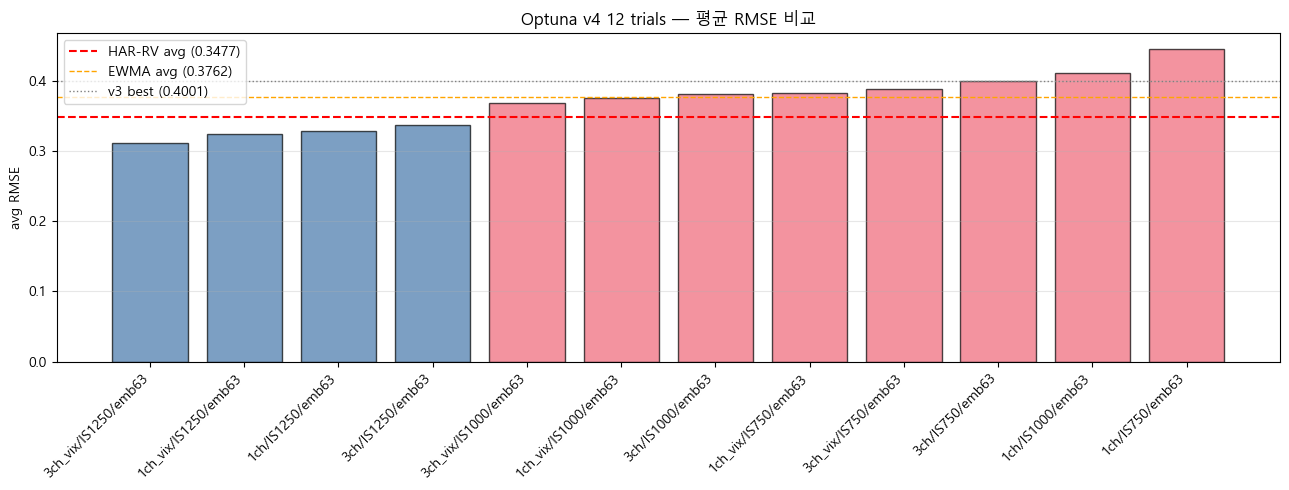

In [8]:
import matplotlib.pyplot as plt

# §8.A. Trial 별 RMSE bar
fig, ax = plt.subplots(figsize=(13, 5))
df_sorted = df_trials.sort_values('avg_rmse').reset_index(drop=True)
labels = [
    f"{r['input_channels']}/IS{r['is_len']}/emb{r['embargo']}"
    for _, r in df_sorted.iterrows()
]
colors = ['#4477AA' if r['avg_rmse'] < BASELINE_RMSE['har']['avg'] else '#EE6677'
          for _, r in df_sorted.iterrows()]
ax.bar(range(len(df_sorted)), df_sorted['avg_rmse'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.5, ls='--',
           label=f'HAR-RV avg ({BASELINE_RMSE["har"]["avg"]:.4f})')
ax.axhline(BASELINE_RMSE['ewma']['avg'], color='orange', lw=1.0, ls='--',
           label=f'EWMA avg ({BASELINE_RMSE["ewma"]["avg"]:.4f})')
ax.axhline(0.4001, color='gray', lw=1.0, ls=':',
           label='v3 best (0.4001)')
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('avg RMSE')
ax.set_title('Optuna v4 12 trials — 평균 RMSE 비교')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


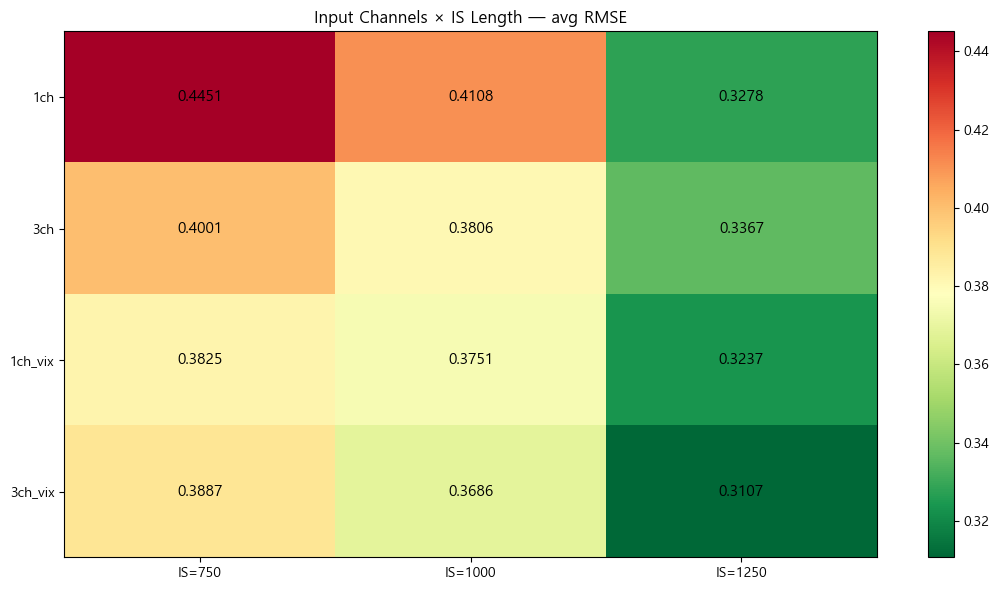

In [9]:
# §8.B. Input Channels × IS Interaction
fig, ax = plt.subplots(figsize=(11, 6))
input_order = ['1ch', '3ch', '1ch_vix', '3ch_vix']
is_order = [750, 1000, 1250]
import numpy as np
matrix = np.full((len(input_order), len(is_order)), np.nan)
for _, row in df_trials.iterrows():
    i = input_order.index(row['input_channels'])
    j = is_order.index(row['is_len'])
    matrix[i, j] = row['avg_rmse']
im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(is_order)))
ax.set_xticklabels([f'IS={x}' for x in is_order])
ax.set_yticks(range(len(input_order)))
ax.set_yticklabels(input_order)
for i in range(len(input_order)):
    for j in range(len(is_order)):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f'{matrix[i,j]:.4f}', ha='center', va='center',
                    color='white' if matrix[i,j] > 0.5 else 'black', fontsize=11)
ax.set_title('Input Channels × IS Length — avg RMSE')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


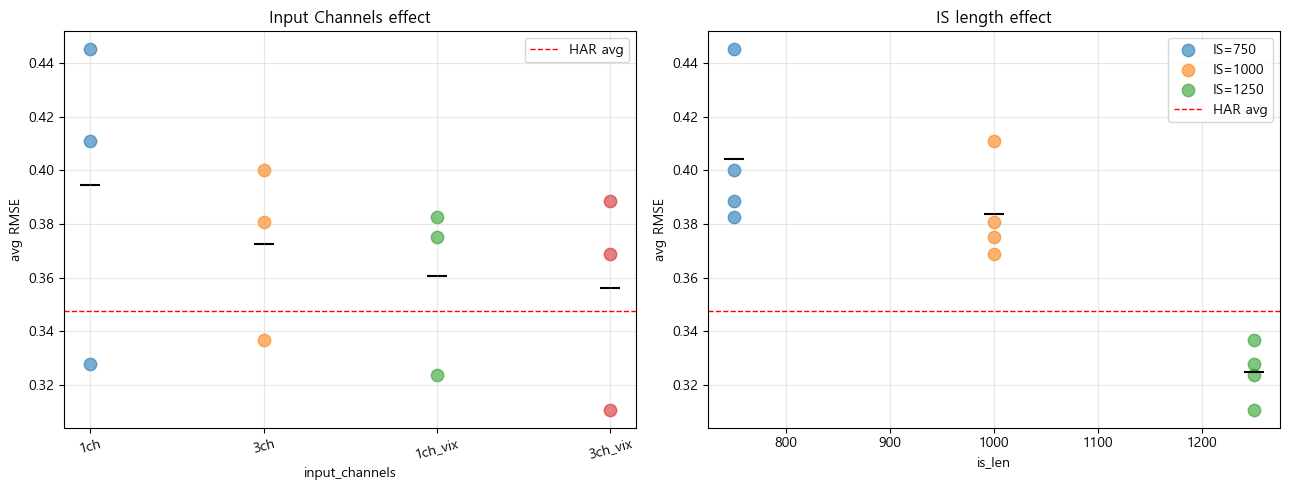

In [10]:
# §8.C. 변수별 marginal effect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# input_channels 효과
ax = axes[0]
for ch in input_order:
    sub = df_trials[df_trials['input_channels'] == ch]
    ax.scatter([ch] * len(sub), sub['avg_rmse'], s=80, alpha=0.6)
    ax.scatter([ch], [sub['avg_rmse'].mean()], s=200, marker='_', color='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.0, ls='--', label='HAR avg')
ax.set_title('Input Channels effect')
ax.set_ylabel('avg RMSE')
ax.set_xlabel('input_channels')
ax.tick_params(axis='x', rotation=15)
ax.legend()
ax.grid(alpha=0.3)

# is_len 효과
ax = axes[1]
for is_l in is_order:
    sub = df_trials[df_trials['is_len'] == is_l]
    ax.scatter([is_l] * len(sub), sub['avg_rmse'], s=80, alpha=0.6, label=f'IS={is_l}')
    ax.scatter([is_l], [sub['avg_rmse'].mean()], s=200, marker='_', color='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.0, ls='--', label='HAR avg')
ax.set_title('IS length effect')
ax.set_ylabel('avg RMSE')
ax.set_xlabel('is_len')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## §9. 결론 + `lstm_optuna_v4_summary.md` 자동 생성


In [11]:
# Best metrics 저장
best_metrics = {
    'best_params': study.best_params,
    'best_avg_rmse': float(study.best_value),
    'best_trial': int(df_trials.iloc[0]['trial']),
    'all_trials': trial_records,
    'baseline_rmse': BASELINE_RMSE,
    'gate1_pass': bool(study.best_value < BASELINE_RMSE['har']['avg']),
    'v3_best_rmse': 0.4001,
    'hyperparams_fixed': {
        'hidden_size': HIDDEN, 'dropout': DROPOUT, 'lr': LR,
        'weight_decay': WEIGHT_DECAY, 'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE, 'batch_size': BATCH_SIZE, 'seed': SEED,
    },
    'analysis_period': [ANALYSIS_START, ANALYSIS_END],
    'n_valid': N_VALID,
    'vix_added': True,
}
metrics_path = OPTUNA_DIR / 'best_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(best_metrics, f, ensure_ascii=False, indent=2)
print(f'저장: {metrics_path}')


# Summary markdown
summary_path = OPTUNA_DIR / 'lstm_optuna_v4_summary.md'
lines = []
lines.append('# Phase 1.5 v4 — VIX + IS 1000/1250 Optuna 결과 요약')
lines.append('')
lines.append(f'> 분석 기간: {ANALYSIS_START} ~ {ANALYSIS_END}')
lines.append(f'> Search Space: 12 unique 조합 (input × is_len × embargo)')
lines.append(f'> 고정: hidden=32, dropout=0.3, lr=1e-3 (v3 동일)')
lines.append(f'> 외생변수: VIX (CBOE Volatility Index)')
lines.append('')
lines.append('## 1. Best 조합')
lines.append('')
lines.append(f'- **input_channels**: `{study.best_params["input_channels"]}`')
lines.append(f'- **is_len**: `{study.best_params["is_len"]}`')
lines.append(f'- **embargo**: `{study.best_params["embargo"]}`')
lines.append(f'- **best avg RMSE**: `{study.best_value:.4f}`')
lines.append(f'- **vs HAR (0.3477)**: {study.best_value - BASELINE_RMSE["har"]["avg"]:+.4f}')
lines.append(f'- **vs v3 best (0.4001)**: {study.best_value - 0.4001:+.4f}')
lines.append('')
lines.append('## 2. 12 Trials 전체 결과 (avg_rmse 오름차순)')
lines.append('')
lines.append('| rank | input | IS | emb | n_folds | SPY RMSE | QQQ RMSE | 평균 RMSE | vs HAR |')
lines.append('|---|---|---|---|---|---|---|---|---|')
for i, row in df_trials.iterrows():
    diff_har = row['avg_rmse'] - BASELINE_RMSE['har']['avg']
    sign = '+' if diff_har >= 0 else ''
    lines.append(
        f'| {i+1} | {row["input_channels"]} | {row["is_len"]} | {row["embargo"]} | '
        f'{row["n_folds"]} | {row["spy_rmse"]:.4f}±{row["spy_rmse_std"]:.3f} | '
        f'{row["qqq_rmse"]:.4f}±{row["qqq_rmse_std"]:.3f} | '
        f'{row["avg_rmse"]:.4f} | {sign}{diff_har:.4f} |'
    )
lines.append('')
lines.append('## 3. 베이스라인 비교')
lines.append('')
lines.append('| 모델 | 평균 RMSE |')
lines.append('|---|---|')
lines.append(f'| **v4 best LSTM** | **{study.best_value:.4f}** |')
lines.append(f'| v3 best LSTM | 0.4001 |')
lines.append(f'| HAR-RV | {BASELINE_RMSE["har"]["avg"]:.4f} |')
lines.append(f'| EWMA | {BASELINE_RMSE["ewma"]["avg"]:.4f} |')
lines.append(f'| Naive | {BASELINE_RMSE["naive"]["avg"]:.4f} |')
lines.append(f'| Train-Mean | {BASELINE_RMSE["train_mean"]["avg"]:.4f} |')
lines.append('')
lines.append('## 4. 관문 1 재판정')
lines.append('')
lines.append(f'- 조건: best LSTM avg RMSE < HAR 평균 RMSE')
lines.append(f'- best: {study.best_value:.4f}')
lines.append(f'- HAR : {BASELINE_RMSE["har"]["avg"]:.4f}')
gate1 = study.best_value < BASELINE_RMSE['har']['avg']
lines.append(f'- **결과: {"PASS (LSTM 우위!)" if gate1 else "FAIL (HAR 우위)"}**')
lines.append('')
lines.append('## 5. 변수별 marginal effect')
lines.append('')
ic_avg = df_trials.groupby('input_channels')['avg_rmse'].mean()
is_avg = df_trials.groupby('is_len')['avg_rmse'].mean()
lines.append(f'### Input Channels')
for ch, rmse in ic_avg.sort_values().items():
    lines.append(f'- `{ch}`: {rmse:.4f}')
lines.append('')
lines.append(f'### IS length')
for is_l, rmse in is_avg.sort_values().items():
    lines.append(f'- `IS={is_l}`: {rmse:.4f}')
lines.append('')
lines.append('## 6. 결론')
lines.append('')
if gate1:
    lines.append('**관문 1 PASS** — v4 best 가 HAR 능가. Phase 1.5 결론 변경 필요.')
elif study.best_value < 0.4001:
    diff = 0.4001 - study.best_value
    pct = diff / 0.4001 * 100
    lines.append(f'**관문 1 FAIL** — HAR 능가는 못 했지만 v3 대비 {pct:.1f}% 추가 개선.')
else:
    lines.append('**관문 1 FAIL** — v4 의 추가 차원 (VIX, IS 확장) 도 효과 제한적.')
    lines.append('Phase 1.5 의 "LSTM 부적합" 결론 더 강화.')
lines.append('')

with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {summary_path}')


print()
print('=' * 80)
print('Phase 1.5 v4 — VIX + IS 확장 Optuna GridSearch 완료')
print('=' * 80)
print(f'best params : {study.best_params}')
print(f'best avg RMSE: {study.best_value:.4f}')
print(f'관문 1 (vs HAR {BASELINE_RMSE["har"]["avg"]:.4f}): '
      f'{"PASS" if gate1 else "FAIL"}')
print(f'v3 대비       : {study.best_value - 0.4001:+.4f}')
print()
print('산출물:')
print(f'  {csv_path.relative_to(BASE_DIR)}')
print(f'  {metrics_path.relative_to(BASE_DIR)}')
print(f'  {summary_path.relative_to(BASE_DIR)}')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna_v4\best_metrics.json
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna_v4\lstm_optuna_v4_summary.md

Phase 1.5 v4 — VIX + IS 확장 Optuna GridSearch 완료
best params : {'input_channels': '3ch_vix', 'is_len': 1250, 'embargo': 63}
best avg RMSE: 0.3107
관문 1 (vs HAR 0.3477): PASS
v3 대비       : -0.0894

산출물:
  results\lstm_optuna_v4\all_trials.csv
  results\lstm_optuna_v4\best_metrics.json
  results\lstm_optuna_v4\lstm_optuna_v4_summary.md
